In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RepeatedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

In [2]:
# =========================
# CONFIG
# =========================
TARGET = "delay_days"
DELAY_THRESHOLD = 5            # for derived classification check
USE_LOG_TARGET = True       # log1p transform to tame skew   -> log1p = log(1+x)
USE_SAMPLE_WEIGHTS = True      # emphasize larger delays during training
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 821 entries, 0 to 820
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   bill_id                           821 non-null    int64  
 1   bill_id_dup                       821 non-null    int64  
 2   vendor_id                         821 non-null    int64  
 3   bni_created_time                  821 non-null    object 
 4   delay_days                        821 non-null    int64  
 5   po_date_dt                        821 non-null    object 
 6   receipt_dt                        821 non-null    object 
 7   shipment_days                     821 non-null    float64
 8   promised_transit_days             821 non-null    float64
 9   days_until_eta                    821 non-null    float64
 10  days_since_ship_so_far            821 non-null    float64
 11  lead_time_days                    821 non-null    float64
 12  scac    

In [5]:
df.drop(columns=['bill_id',	'bill_id_dup',	'vendor_id',	'bni_created_time','po_date_dt','receipt_dt'], inplace=True)

In [6]:
# =========================
# SPLIT + TARGET
# =========================
df = df.copy()
# (optional) clip impossible outliers while keeping signal
df[TARGET] = np.clip(df[TARGET], 0, 30)         # clipping the maximum delay to 30 days

y = df[TARGET].astype(float)
X = df.drop(columns=[TARGET])

X_train, X_test, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [7]:
# target transform (log1p helps a lot with right-skew)
if USE_LOG_TARGET:
    y_train = np.log1p(y_train_raw)
    y_test  = np.log1p(y_test_raw)
    inv = np.expm1
else:
    y_train = y_train_raw.copy()
    y_test  = y_test_raw.copy()
    inv = lambda z: z

In [8]:
# regression “balancing”: sample weights that up-weight long delays
if USE_SAMPLE_WEIGHTS:
    rng = (y_train_raw.max() - y_train_raw.min()) or 1.0
    w_train = 1.0 + (y_train_raw - y_train_raw.min()) / rng           # ~[1,2]
    # for stronger emphasis use: np.exp((y_train_raw - y_train_raw.min()) / rng)
else:
    w_train = None

In [9]:
# =========================
# PREPROCESSING
# =========================
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

In [10]:
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

In [11]:
# preprocess = ColumnTransformer(
#     transformers=[
#         ("num", "passthrough", num_cols),
#         ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
#     ],
#     remainder="drop"
# )

In [12]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols,
        ),
    ],
    remainder="drop",
)

In [13]:
# =========================
# MODEL + GRID
# =========================
gbr = GradientBoostingRegressor(
    random_state=RANDOM_STATE,
    loss="absolute_error"  # try 'huber' for outlier-robust training
)

pipe = Pipeline([("prep", preprocess), ("model", gbr)])

param_grid = {
    "model__n_estimators": [600, 700],
    "model__learning_rate": [0.01, 0.001],
    "model__max_depth": [3, 5,7, 9],
    "model__subsample": [1.0, 0.8],
    "model__min_samples_leaf": [1, 2]
}

cv = RepeatedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE)

gs = GridSearchCV(
    pipe,
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

In [14]:
# fit (pass sample_weight if enabled)
fit_kwargs = {"model__sample_weight": w_train} if w_train is not None else {}
gs.fit(X_train, y_train, **fit_kwargs)

best_gbr = gs.best_estimator_
print("Best params:", gs.best_params_)

# =========================
# EVALUATE (on original scale)
# =========================
y_pred_test = inv(best_gbr.predict(X_test))
y_true_test = y_test_raw

mae  = mean_absolute_error(y_true_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
r2   = r2_score(y_true_test, y_pred_test)
print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}")

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 9, 'model__min_samples_leaf': 2, 'model__n_estimators': 700, 'model__subsample': 0.8}
MAE=0.820  RMSE=2.170  R²=0.499


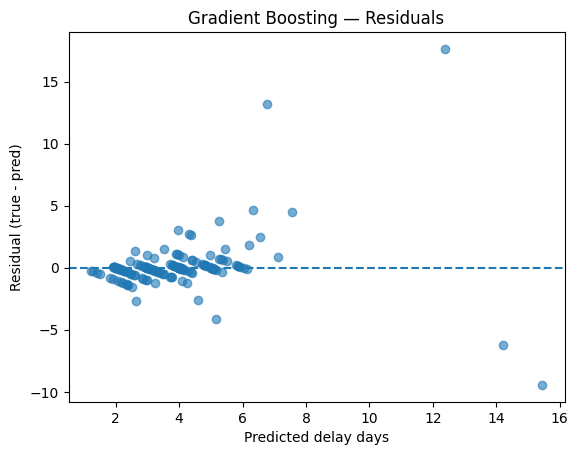

In [15]:
# residuals
resid = y_true_test - y_pred_test
plt.figure()
plt.scatter(y_pred_test, resid, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted delay days")
plt.ylabel("Residual (true - pred)")
plt.title("Gradient Boosting — Residuals")
plt.show()

In [16]:
# =========================
# PERMUTATION IMPORTANCE
# =========================
# build post-encoding feature names
# ohe = best_gbr.named_steps["prep"].named_transformers_.get("cat", None)
# ohe_cols = ohe.get_feature_names_out(cat_cols).tolist() if ohe is not None else []
# feat_names = num_cols + ohe_cols

# use log target for importance if you trained in log space
target_for_importance = y_test if USE_LOG_TARGET else y_test_raw

# perm = permutation_importance(best_gbr, X_test, target_for_importance, n_repeats=10,
#                               random_state=RANDOM_STATE, n_jobs=-1)
# imp = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)
# print("\nTop 20 permutation importances:")
# print(imp.head(20))

# plt.figure(figsize=(8, 10))
# imp.head(25).iloc[::-1].plot(kind="barh")
# plt.title("Permutation Importance — Gradient Boosting")
# plt.tight_layout()
# plt.show()


Derived classification (threshold > 5 days):
[[131   9]
 [  4  21]]
              precision    recall  f1-score   support

           0      0.970     0.936     0.953       140
           1      0.700     0.840     0.764        25

    accuracy                          0.921       165
   macro avg      0.835     0.888     0.858       165
weighted avg      0.929     0.921     0.924       165



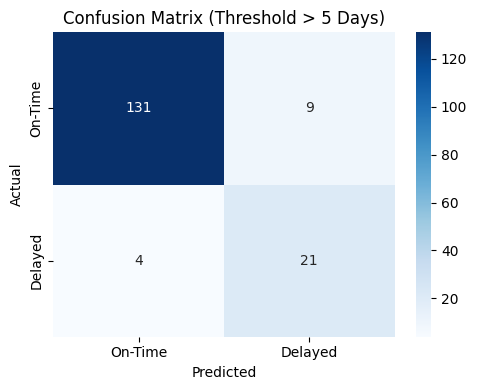

In [17]:
# =========================
# OPTIONAL: derive classification (>5 days)
# =========================
pred_is_delayed = (y_pred_test > DELAY_THRESHOLD).astype(int)
actual_is_delayed = (y_true_test > DELAY_THRESHOLD).astype(int)

print("\nDerived classification (threshold > 5 days):")
print(confusion_matrix(actual_is_delayed, pred_is_delayed))
print(classification_report(actual_is_delayed, pred_is_delayed, digits=3))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# --- Confusion Matrix Plot ---
cm = confusion_matrix(actual_is_delayed, pred_is_delayed)
labels = ['On-Time', 'Delayed']

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix (Threshold > 5 Days)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Inferencing

In [ ]:
import pandas as pd
import numpy as np

# Single new observation
new_data = pd.DataFrame([
     {
    "po_date_dt": "2025-05-02 00:00:00+00:00",
    "shipment_days": 60.0,
    "promised_transit_days": 60.0,
    "days_until_eta": 23.0,
    "days_since_ship_so_far": 37.0,
    "lead_time_days": 146.0,
    "scac": "CMDU",
    "tariff_amount": 0.0,
    "ocean_freight": 0.0,
    "delivery_terms": "CY",
    "po_shipment_terms": "DDP",
    "tariff_type": "Price With Tariff",
    "total_bcy": 1828687.4,
    "quantity_in": 34020.0,
    "item_sku": 857,
    "item_brand": "GREAT VALUE",
    "item_manufacturer": "VANNAMEI",
    "item_size": "71/90",
    "vendor_avg_promised_transit_days": 56.59,
    "vendor_p50_promised_transit_days": 51.0,
    "vendor_p90_promised_transit_days": 74.0,
    "vendor_avg_realized_delay_days": 3.92,
    "vendor_p50_realized_delay_days": 4.0,
    "vendor_p90_realized_delay_days": 6.0,
    "vendor_on_time_rate": 0.0,
    "vendor_shipments_with_receipt": 78,
    "shipped_date_weekday": 3,
    "shipped_date_month": 9,
    "shipped_date_day": 25,
    "distance_nm": 1100
}

])

# Keep columns in the same order as training
new_data = new_data[X.columns]

new_data[num_cols] = new_data[num_cols].astype(float)


In [52]:
X.columns

Index(['shipment_days', 'promised_transit_days', 'days_until_eta',
       'days_since_ship_so_far', 'lead_time_days', 'scac', 'tariff_amount',
       'ocean_freight', 'delivery_terms', 'po_shipment_terms', 'tariff_type',
       'total_bcy', 'quantity_in', 'item_sku', 'item_brand',
       'item_manufacturer', 'item_size', 'vendor_avg_promised_transit_days',
       'vendor_p50_promised_transit_days', 'vendor_p90_promised_transit_days',
       'vendor_avg_realized_delay_days', 'vendor_p50_realized_delay_days',
       'vendor_p90_realized_delay_days', 'vendor_on_time_rate',
       'vendor_shipments_with_receipt', 'shipped_date_weekday',
       'shipped_date_month', 'shipped_date_day', 'distance_nm'],
      dtype='object')

In [53]:
new_data

,shipment_days,promised_transit_days,days_until_eta,days_since_ship_so_far,lead_time_days,scac,tariff_amount,ocean_freight,delivery_terms,po_shipment_terms,...,vendor_p90_promised_transit_days,vendor_avg_realized_delay_days,vendor_p50_realized_delay_days,vendor_p90_realized_delay_days,vendor_on_time_rate,vendor_shipments_with_receipt,shipped_date_weekday,shipped_date_month,shipped_date_day,distance_nm
0,690.0,60.0,23.0,37.0,146.0,CMDU,0.0,0.0,CY,DDP,...,74.0,3.92,4.0,6.0,0.0,78.0,3.0,9.0,25.0,1100.0


In [54]:
# Use trained pipeline (best_gbr from your GridSearchCV)
predicted_delay_log = best_gbr.predict(new_data)

# If you trained with log1p transform
predicted_delay_days = np.expm1(predicted_delay_log)

print(f"Predicted Delay Days: {predicted_delay_days[0]:.2f}")


Predicted Delay Days: 22.88


In [50]:
is_predicted_delayed = int(predicted_delay_days[0] > 5)
print("Predicted Class:", "DELAYED" if is_predicted_delayed else "ON-TIME")

Predicted Class: ON-TIME


## Explaning the result of Gradient Boosting

/Users/prashant/.pyenv/versions/3.13.7/envs/ideabox-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


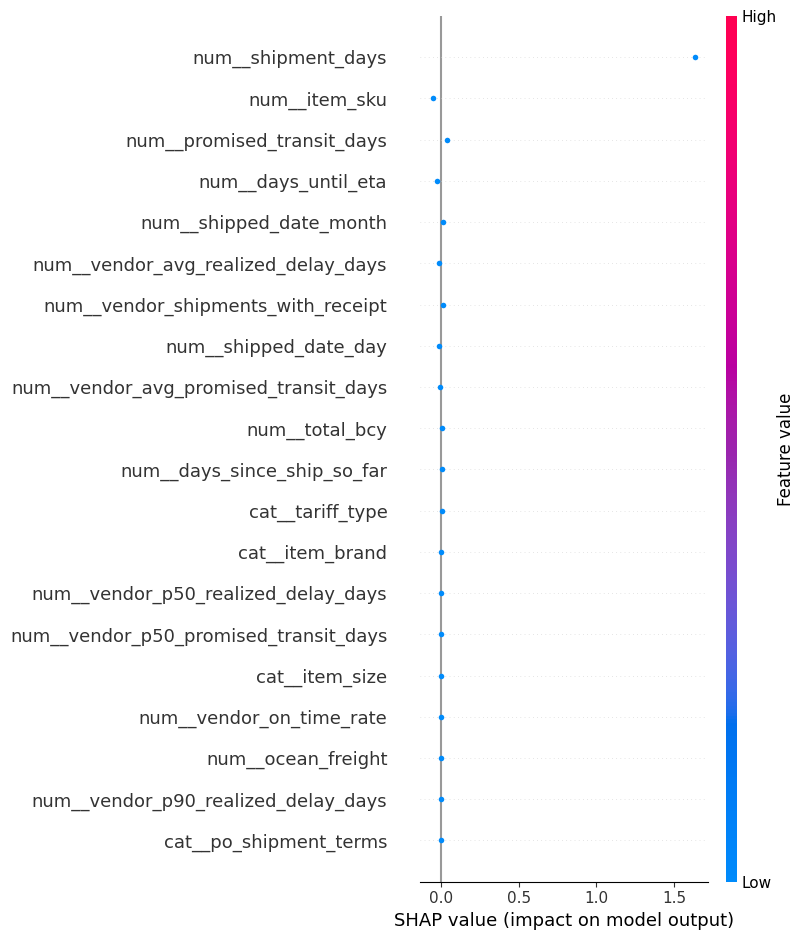

In [72]:
import shap

# Create SHAP explainer
explainer = shap.Explainer(best_gbr.named_steps['model'], 
                           feature_names=best_gbr.named_steps['prep'].get_feature_names_out())

# Compute SHAP values on your test data
X_test_transformed = best_gbr.named_steps['prep'].transform(new_data)
shap_values = explainer(X_test_transformed)

# Global summary plot
shap.summary_plot(shap_values, features=X_test_transformed, feature_names=best_gbr.named_steps['prep'].get_feature_names_out())


In [73]:
new_data

,shipment_days,promised_transit_days,days_until_eta,days_since_ship_so_far,lead_time_days,scac,tariff_amount,ocean_freight,delivery_terms,po_shipment_terms,...,vendor_p90_promised_transit_days,vendor_avg_realized_delay_days,vendor_p50_realized_delay_days,vendor_p90_realized_delay_days,vendor_on_time_rate,vendor_shipments_with_receipt,shipped_date_weekday,shipped_date_month,shipped_date_day,distance_nm
0,690.0,60.0,23.0,37.0,146.0,CMDU,0.0,0.0,CY,DDP,...,74.0,3.92,4.0,6.0,0.0,78.0,3.0,9.0,25.0,1100.0


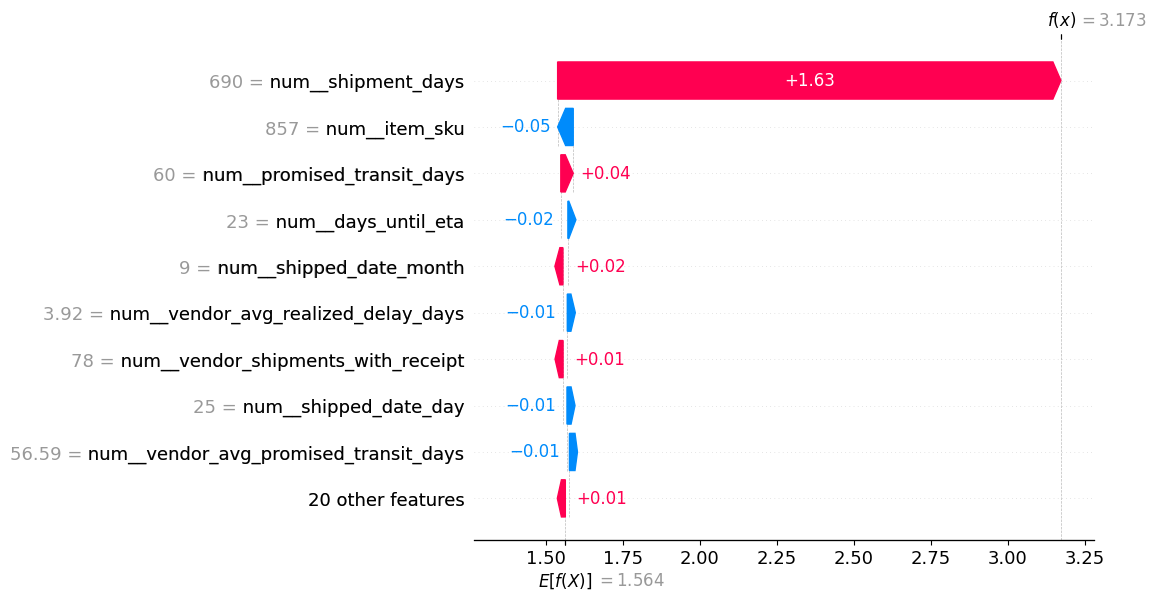

In [74]:
# 1️⃣ Transform the new data
new_data_transformed = best_gbr.named_steps['prep'].transform(new_data)

# 2️⃣ Get SHAP values
shap_values_single = explainer(new_data_transformed)

# 3️⃣ Visualize explanation for that one prediction
shap.plots.waterfall(shap_values_single[0])


In [75]:
(shap_values_single[0])

.values =
array([ 1.63383977e+00,  4.02917071e-02, -2.29979369e-02,  5.67584367e-03,
       -7.47993690e-05,  4.40527242e-04, -1.28442632e-03,  7.00233191e-03,
        2.64813877e-04, -5.06141790e-02, -7.99439959e-03,  1.62058033e-03,
       -9.58699488e-04, -1.42781456e-02, -1.89973495e-03, -1.14980677e-03,
       -1.40102856e-03,  1.38101548e-02,  2.81028601e-04,  1.61942461e-02,
       -1.27694597e-02, -3.37451797e-04, -1.46880570e-04, -8.49752506e-08,
       -1.14899869e-03,  4.55084995e-03,  3.19557113e-03,  2.15216785e-04,
       -1.46730338e-03])

.base_values =
np.float64(1.5640520115757532)

.data =
array([6.9000000e+02, 6.0000000e+01, 2.3000000e+01, 3.7000000e+01,
       1.4600000e+02, 0.0000000e+00, 0.0000000e+00, 1.8286874e+06,
       3.4020000e+04, 8.5700000e+02, 5.6590000e+01, 5.1000000e+01,
       7.4000000e+01, 3.9200000e+00, 4.0000000e+00, 6.0000000e+00,
       0.0000000e+00, 7.8000000e+01, 3.0000000e+00, 9.0000000e+00,
       2.5000000e+01, 1.1000000e+03, 0.0000000e+0

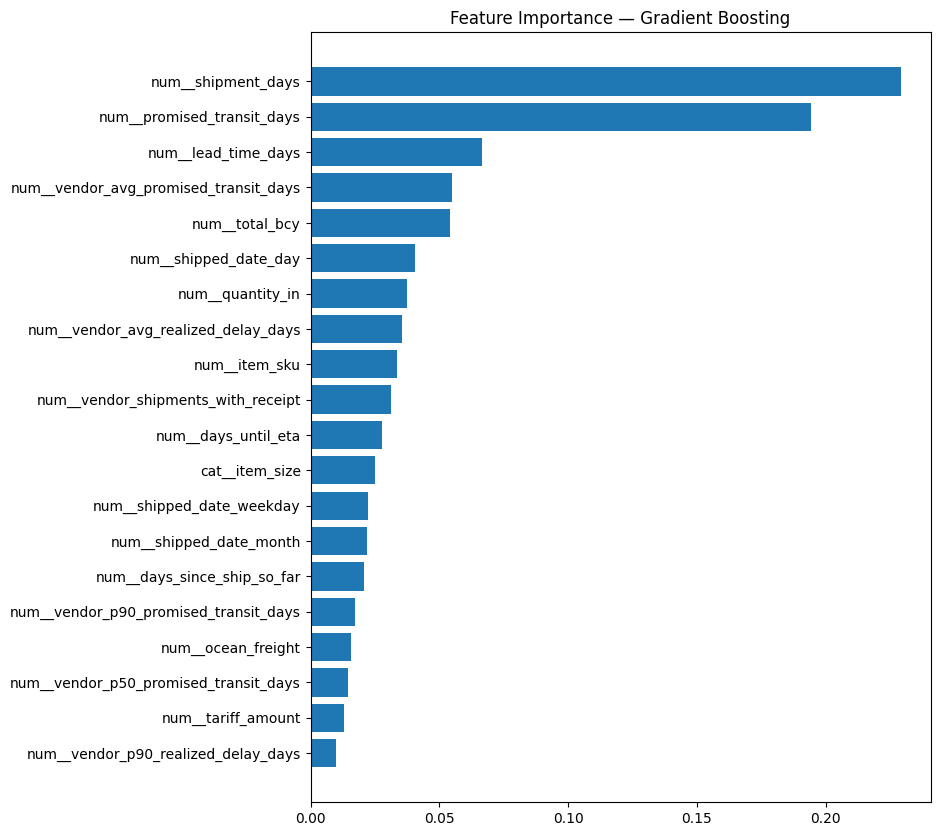

In [76]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = best_gbr.named_steps['prep'].get_feature_names_out()
importances = best_gbr.named_steps['model'].feature_importances_

# Sort and plot
indices = np.argsort(importances)[-20:]
plt.figure(figsize=(8, 10))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Feature Importance — Gradient Boosting")
plt.show()

## Explaning using LLM

In [77]:
from pydantic import BaseModel, Field

class ShipmentExplanation(BaseModel):
    reasonings: list[str] = Field(..., description="List of reasonings for the predicted shipment delay. First item should contain how many days of delay was predicted.")

In [78]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv()


def generate_response(user_query):

    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    system_prompt = """You are an expert data scientist specializing in machine learning model output explanations and the reasoning behind them. 
    Your task is to help explain the predictions of a model and come up with appropriate reasons for the shipment delay.
    The feature values that are used for the classification task are also provided 
    Focus on the most impactful features and how they may have influenced the delay.
    Try to keep the explanation based on the data provided.
    Avoid using technical jargon; explain in simple terms.
    Try to explain the predictions in bullet points should be **short and concise such that it is quick for customers to grasp**
    Do not use the feature names directly in the explanation.
    Try to back up the reasonings with the numerical value wherever possible.

    Here is the idea behind the features provided:
    - shipping_duration_days: Expected duration of the shipment in days.
    - lead_time_days: Number of days between order placement and shipment.
    - is_early_delivery: Indicator if the delivery was early (1) or not (0).
    - coo: Country of origin of the shipment.
    - scac: Standard Carrier Alpha Code representing the shipping carrier.
    - tariff_amount: The tariff cost associated with the shipment.
    - ocean_freight: Cost of ocean freight for the shipment.
    - delivery_terms: Terms of delivery (e.g., CY, DDP).
    - po_shipment_terms: Purchase order shipment terms.
    - tariff_type: Type of tariff applied to the shipment.
    - total_bcy: Total cost in base currency.
    - quantity_in: Quantity of items in the shipment.
    - item_sku: Stock Keeping Unit identifier for the item.
    - item_brand: Brand of the item being shipped.
    - item_manufacturer: Manufacturer of the item.
    - item_product_category: Category of the product being shipped.
    - item_size: Size specification of the item.
    - vendor_name: Name of the vendor supplying the item.
    - vendor_avg_delay_days: Average delay days for shipments from this vendor.
    - vendor_shipments: Total number of shipments made by this vendor.
    - vendor_on_time_rate: Percentage of on-time deliveries by this vendor.
    - vendor_p50_delay_days: 50th percentile delay days for this vendor.
    - vendor_p90_delay_days: 90th percentile delay days for this vendor.
    - shipped_date_weekday: Day of the week the shipment was sent (0=Monday, 6=Sunday).
    - shipped_date_month: Month the shipment was sent (1-12).
    - shipped_date_day: Day of the month the shipment was sent (1-31).
    
    Things to avoid:
    "The day of the week when the shipment was sent may contribute slightly to delays.",  instead write "Shipments sent on (name of the day) may experience minor delays due to operational factors. based on historical data"
    
    Expected Outputs Format
    
    Example 1:
    Predicted delay: ~30 days
    Shipping time: 139 days (high uncertainty)
    Vendor on-time rate: 5% (frequent delays)
    Lead time: 233 days (error-prone)
    Ship day: Friday (weekend hold risk)
    
    Example 2:
    Predicted delay: ~5 days
    Ship day: Monday → operational backlog
    Vendor on-time rate: 33% (high risk)
    Shipping time: 73 days → unexpected issues
    High tariffs/freight: Customs & logistics delays
  
    """

    response = client.responses.parse(
        model="gpt-4o-2024-08-06",
        input=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_query},
        ],
        text_format=ShipmentExplanation,
    )

    return response

In [79]:
import pandas as pd

# Create the DataFrame
df_new = pd.read_csv('./results/raw_shipment_classification_inference_dataset.csv')

df_new.head()

,bill_id,bill_id_dup,vendor_id,vendor_name,bni_created_time,delay_days,po_date_dt,shipment_days,promised_transit_days,days_until_eta,...,vendor_p90_promised_transit_days,vendor_avg_realized_delay_days,vendor_p50_realized_delay_days,vendor_p90_realized_delay_days,vendor_on_time_rate,vendor_shipments_with_receipt,shipped_date_weekday,shipped_date_month,shipped_date_day,distance_nm
0,1410873000132937067,1410873000132937067,1410873000000206411,Aquatica Frozen Foods Global Pvt Ltd,2025-09-30 18:46:58+00:00,5,2025-05-01 00:00:00+00:00,54.0,49.0,-37.0,...,68.0,5.8,4.0,7.0,0.0,100,3,8,7,11000
1,1410873000132937067,1410873000132937067,1410873000000206411,Aquatica Frozen Foods Global Pvt Ltd,2025-09-30 18:46:58+00:00,5,2025-05-01 00:00:00+00:00,54.0,49.0,-37.0,...,68.0,5.8,4.0,7.0,0.0,100,3,8,7,11000
2,1410873000132937067,1410873000132937067,1410873000000206411,Aquatica Frozen Foods Global Pvt Ltd,2025-09-30 18:46:58+00:00,5,2025-05-01 00:00:00+00:00,54.0,49.0,-37.0,...,68.0,5.8,4.0,7.0,0.0,100,3,8,7,11000
3,1410873000132937067,1410873000132937067,1410873000000206411,Aquatica Frozen Foods Global Pvt Ltd,2025-09-30 18:46:58+00:00,5,2025-05-01 00:00:00+00:00,54.0,49.0,-37.0,...,68.0,5.8,4.0,7.0,0.0,100,3,8,7,11000
4,1410873000132937067,1410873000132937067,1410873000000206411,Aquatica Frozen Foods Global Pvt Ltd,2025-09-30 18:46:58+00:00,5,2025-05-01 00:00:00+00:00,54.0,49.0,-37.0,...,68.0,5.8,4.0,7.0,0.0,100,3,8,7,11000


In [80]:
df_new.columns

Index(['bill_id', 'bill_id_dup', 'vendor_id', 'vendor_name',
       'bni_created_time', 'delay_days', 'po_date_dt', 'shipment_days',
       'promised_transit_days', 'days_until_eta', 'days_since_ship_so_far',
       'lead_time_days', 'scac', 'tariff_amount', 'ocean_freight',
       'delivery_terms', 'po_shipment_terms', 'tariff_type', 'total_bcy',
       'quantity_in', 'item_sku', 'item_brand', 'item_manufacturer',
       'item_size', 'vendor_avg_promised_transit_days',
       'vendor_p50_promised_transit_days', 'vendor_p90_promised_transit_days',
       'vendor_avg_realized_delay_days', 'vendor_p50_realized_delay_days',
       'vendor_p90_realized_delay_days', 'vendor_on_time_rate',
       'vendor_shipments_with_receipt', 'shipped_date_weekday',
       'shipped_date_month', 'shipped_date_day', 'distance_nm'],
      dtype='object')

In [81]:
# Drop target if you're predicting (we already have delay_days here, but we can ignore it)
X_new = df_new.drop(columns=["delay_days"])
# X_new = df_new
# Predict delay days
pred_log = best_gbr.predict(X_new)
pred_days = np.expm1(pred_log)
df_new["predicted_delay_days"] = pred_days.round(2)

# Derive classification (delayed vs not delayed)
df_new["predicted_is_delayed"] = (df_new["predicted_delay_days"] > 5).astype(int)

In [82]:
delay_predicted_data = df_new[df_new["predicted_is_delayed"] == 1]

In [83]:
delay_predicted_data.iloc[1, :]

bill_id                                              1410873000132937067
bill_id_dup                                          1410873000132937067
vendor_id                                            1410873000000206411
vendor_name                         Aquatica Frozen Foods Global Pvt Ltd
bni_created_time                               2025-09-30 18:46:58+00:00
delay_days                                                             5
po_date_dt                                     2025-05-01 00:00:00+00:00
shipment_days                                                       54.0
promised_transit_days                                               49.0
days_until_eta                                                     -37.0
days_since_ship_so_far                                              86.0
lead_time_days                                                      98.0
scac                                                                CMDU
tariff_amount                                      

In [84]:
delay_data = delay_predicted_data[X.columns].iloc[[0], :]

In [69]:
(delay_data)

,shipment_days,promised_transit_days,days_until_eta,days_since_ship_so_far,lead_time_days,scac,tariff_amount,ocean_freight,delivery_terms,po_shipment_terms,...,vendor_p90_promised_transit_days,vendor_avg_realized_delay_days,vendor_p50_realized_delay_days,vendor_p90_realized_delay_days,vendor_on_time_rate,vendor_shipments_with_receipt,shipped_date_weekday,shipped_date_month,shipped_date_day,distance_nm
0,54.0,49.0,-37.0,86.0,98.0,CMDU,37408.0,5800.0,CY,DDP,...,68.0,5.8,4.0,7.0,0.0,100,3,8,7,11000


In [88]:
len(delay_predicted_data)

51

In [86]:
for i in range(0,len(delay_predicted_data)):
    all_data = delay_predicted_data.iloc[[i], :]
    print(all_data['predicted_delay_days'].values[0])

5.12
5.12
5.12
5.12
5.12
5.12
5.12
5.12
28.96
28.96
15.9
15.9
8.82
8.82
5.12
5.12
5.12
5.12
9.67
9.67
9.67
9.67
9.67
9.67
9.67
9.67
5.03
5.03
5.03
5.03
5.03
5.03
5.03
5.03
5.66
5.66
26.0
26.0
26.0
26.0
26.0
26.0
26.0
26.0
5.35
5.35
5.35
5.35
5.07
5.07
12.37


In [87]:
for i in range(0,5):
    all_data = delay_predicted_data.iloc[[i], :]
    delay_data = delay_predicted_data[X.columns].iloc[[i], :]
    new_data_transformed = best_gbr.named_steps['prep'].transform(delay_data)
    shap_values_single = explainer(new_data_transformed)
    user_query = f"""Given the following feature values for a shipment:
    {delay_data.to_dict(orient='records')[0]}
    The model predicted a delay of {all_data['predicted_delay_days'].values[0]} days.
    Please explain how the key features influenced this prediction.
    Shap values for the features are:
    {shap_values_single.values[0]}
    """
    response = generate_response(user_query)
    import json

    print(json.loads(response.output_text)['reasonings'])

['Predicted delay: ~5 days', 'Vendor on-time rate: 0% indicates frequent delays', 'Shipping duration: 54 days, slightly above expected, influencing longer transit time', 'Lead time: 98 days suggests potential planning issues', 'Weekday shipping: Wednesday, neutral day but possible mid-week congestion', 'Tariff & freight costs: High costs may cause customs reviews and logistics delays']
['Predicted delay: ~5 days', 'Lead time: 98 days (long preparation period)', 'Vendor on-time rate: 0% (frequent delays)', 'Shipping duration: 54 days (higher than average)', 'Tariff costs: Impacts delivery process and timing']
['Predicted delay: ~5 days', 'Vendor on-time rate: 0% (very frequent delays)', 'Lead time: 98 days (long and error-prone)', 'Tariff and freight costs: High potential for customs delays', 'Ship day: Wednesday (less impact but minor shipping adjustments)']
['Predicted delay: ~5 days', 'Vendor on-time rate: 0% (consistent past delays of 5.8 days on average)', 'Promised transit days: L

In [ ]:
print(dir(response))

In [ ]:
import json

json.loads(response.output_text)['reasonings']